---
**ISBM COLLEGE OF ENGINEERING**  
**SUBJECT**: BDA LAB  
**STUDENT NAME**: RUSHIL CHAITANYA DHUBE  
**ROLL NUMBER**: 12  
**YEAR**: BE (2025-2026)  
**PRACTICAL**: 5

---

# MapReduce Implementation for Movie Rating Analysis

## Lab Objectives:
1. Understand MapReduce paradigm for distributed computing
2. Implement Map function to emit movie ratings
3. Implement Reduce function to calculate average ratings
4. Process movies dataset using MapReduce
5. Analyze and visualize movie rating statistics
6. Compare with pandas/numpy implementations

In [9]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import os
from datetime import datetime

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print(f"Current working directory: {os.getcwd()}")

Current working directory: d:\BDA LAB\Movie Dataset


## Step 1: Load and Explore Movies Dataset

In [10]:
print("=" * 70)
print("STEP 1: LOAD AND EXPLORE MOVIES DATASET")
print("=" * 70)

# Use the provided CSV file explicitly
dataset_file = 'movies.csv'
print(f"\nTarget dataset file: {dataset_file}")

if os.path.exists(dataset_file):
    print(f"Loading dataset: {dataset_file}")
    raw_df = pd.read_csv(dataset_file)
    print("\nDataset loaded successfully from movies.csv!")
else:
    raise FileNotFoundError("movies.csv not found in current directory. Please place it in Movie Dataset folder.")

# Show all available attributes from CSV
print("\nCSV Attributes (Columns):")
print("-" * 70)
for i, col in enumerate(raw_df.columns.tolist(), 1):
    print(f"{i:2d}. {col}")

print("\nAttribute Data Types:")
print("-" * 70)
print(raw_df.dtypes)

print("\nMissing Values by Attribute (Top 15):")
print("-" * 70)
print(raw_df.isna().sum().sort_values(ascending=False).head(15))

# Build a MapReduce-friendly dataframe with required columns from actual movie attributes
required_cols = ['id', 'title', 'director', 'genres', 'release_date', 'vote_average', 'vote_count']
missing_cols = [c for c in required_cols if c not in raw_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in movies.csv: {missing_cols}")

prep_df = raw_df[required_cols].copy()
prep_df = prep_df.dropna(subset=['id', 'vote_average'])
prep_df['id'] = pd.to_numeric(prep_df['id'], errors='coerce')
prep_df['vote_average'] = pd.to_numeric(prep_df['vote_average'], errors='coerce')
prep_df['vote_count'] = pd.to_numeric(prep_df['vote_count'], errors='coerce').fillna(0)
prep_df = prep_df.dropna(subset=['id', 'vote_average'])

# Keep rating in a 0-5 range for consistency with the rest of this practical
prep_df['rating'] = (prep_df['vote_average'] / 2.0).clip(lower=0, upper=5)

# Create metadata lookup for later analysis tables
movie_meta = prep_df.set_index('id')[['title', 'director', 'genres', 'release_date', 'vote_count']].to_dict('index')

# Final dataframe used by the MapReduce pipeline
df = prep_df.rename(columns={'id': 'movie_id'})[['movie_id', 'vote_count', 'rating']]
df['user_id'] = df['vote_count'].round().astype(int)
df['timestamp'] = pd.Timestamp('2023-01-01').timestamp()
df = df[['movie_id', 'user_id', 'rating', 'timestamp']]

print(f"\nDataset Shape (prepared for MapReduce): {df.shape}")
print(f"\nFirst 10 rows (prepared data):")
print(df.head(10))
print(f"\nPrepared Dataset Info:")
print(df.info())
print(f"\nPrepared Dataset Statistics:")
print(df.describe())

STEP 1: LOAD AND EXPLORE MOVIES DATASET

Target dataset file: movies.csv
Loading dataset: movies.csv

 Dataset loaded successfully from movies.csv!

CSV Attributes (Columns):
----------------------------------------------------------------------
 1. index
 2. budget
 3. genres
 4. homepage
 5. id
 6. keywords
 7. original_language
 8. original_title
 9. overview
10. popularity
11. production_companies
12. production_countries
13. release_date
14. revenue
15. runtime
16. spoken_languages
17. status
18. tagline
19. title
20. vote_average
21. vote_count
22. cast
23. crew
24. director

Attribute Data Types:
----------------------------------------------------------------------
index                     int64
budget                    int64
genres                      str
homepage                    str
id                        int64
keywords                    str
original_language           str
original_title              str
overview                    str
popularity              float6

## Step 2: MapReduce Implementation

In [11]:
print("\n" + "=" * 70)
print("STEP 2: MAPREDUCE IMPLEMENTATION")
print("=" * 70)

# ============================================================================
# MAP FUNCTION
# ============================================================================
def map_function(record):
    """
    Map function: Extract movie_id and rating from each record
    
    Input: A record with format: [movie_id, user_id, rating, timestamp]
    Output: Tuple (movie_id, rating)
    """
    try:
        # Handle list/tuple records directly from DataFrame values
        if isinstance(record, (list, tuple, np.ndarray)):
            movie_id = int(float(record[0]))
            rating = float(record[2])
            return (movie_id, rating)

        # Fallback for string/line-like input
        parts = str(record).replace(',', ' ').split()
        movie_id = int(float(parts[0]))
        rating = float(parts[2])
        return (movie_id, rating)
    except Exception as e:
        print(f"Error processing record: {record}, Error: {e}")
        return None

# ============================================================================
# REDUCE FUNCTION
# ============================================================================
def reduce_function(movie_ratings):
    """
    Reduce function: Calculate average rating for each movie
    
    Input: Dictionary with movie_id as key and list of ratings as value
           {movie_id: [rating1, rating2, ...]}
    
    Output: Dictionary with movie_id as key and average rating as value
            {movie_id: average_rating}
    """
    result = {}
    
    for movie_id, ratings in movie_ratings.items():
        if ratings:
            total_rating = sum(ratings)
            count = len(ratings)
            average_rating = total_rating / count
            
            result[movie_id] = {
                'average_rating': average_rating,
                'total_ratings': count,
                'sum_ratings': total_rating
            }
    
    return result

print("\nMap function defined")
print("Reduce function defined")
print("\nFunction Descriptions:")
print("-" * 70)
print("MAP FUNCTION:")
print("  - Input: Record (movie_id, user_id, rating, timestamp)")
print("  - Output: (movie_id, rating)")
print("  - Purpose: Extract and emit key-value pairs")
print("\nREDUCE FUNCTION:")
print("  - Input: Dictionary {movie_id: [ratings]}")
print("  - Output: Dictionary {movie_id: {average_rating, count}}")
print("  - Purpose: Calculate average rating per movie")


STEP 2: MAPREDUCE IMPLEMENTATION

 Map function defined
 Reduce function defined

Function Descriptions:
----------------------------------------------------------------------
MAP FUNCTION:
  - Input: Record (movie_id, user_id, rating, timestamp)
  - Output: (movie_id, rating)
  - Purpose: Extract and emit key-value pairs

REDUCE FUNCTION:
  - Input: Dictionary {movie_id: [ratings]}
  - Output: Dictionary {movie_id: {average_rating, count}}
  - Purpose: Calculate average rating per movie


## Step 3: Execute MapReduce Pipeline

In [12]:
print("\n" + "=" * 70)
print("STEP 3: EXECUTE MAPREDUCE PIPELINE")
print("=" * 70)

print("\nPhase 1: MAP PHASE")
print("-" * 70)

# Convert DataFrame to list of tuples for mapping
data_lines = df.values.tolist()
print(f"Total records to process: {len(data_lines)}")

# Apply map function to all records
mapped_pairs = []
for i, line in enumerate(data_lines):
    result = map_function(line)
    if result:
        mapped_pairs.append(result)

print(f"Mapped {len(mapped_pairs)} records")
print(f"\nFirst 10 mapped pairs (movie_id, rating):")
for i, pair in enumerate(mapped_pairs[:10]):
    print(f"  {i+1}. {pair}")

# ============================================================================
print("\nPhase 2: SHUFFLE AND SORT (Group by key)")
print("-" * 70)

# Group ratings by movie_id (Shuffle and Sort phase)
movie_ratings = defaultdict(list)
for movie_id, rating in mapped_pairs:
    movie_ratings[movie_id].append(rating)

print(f"Grouped ratings by movie_id")
print(f"Total unique movies: {len(movie_ratings)}")
print(f"\nSample grouped data (movie_id: [ratings]):")
for i, (movie_id, ratings) in enumerate(list(movie_ratings.items())[:5]):
    print(f"  Movie {movie_id}: {len(ratings)} ratings - {ratings[:5]}{'...' if len(ratings) > 5 else ''}")

# ============================================================================
print("\nPhase 3: REDUCE PHASE")
print("-" * 70)

# Apply reduce function
movie_averages = reduce_function(movie_ratings)

print(f"Reduced to {len(movie_averages)} movie averages")
print(f"\nMovie Average Ratings (Top 10):")
print("-" * 70)
print(f"{'Movie ID':<10} {'Avg Rating':<15} {'Total Ratings':<15} {'Sum'}")
print("-" * 70)

sorted_movies = sorted(movie_averages.items(), key=lambda x: x[1]['average_rating'], reverse=True)
for movie_id, stats in sorted_movies[:10]:
    print(f"{movie_id:<10} {stats['average_rating']:<15.4f} {stats['total_ratings']:<15} {stats['sum_ratings']:.2f}")


STEP 3: EXECUTE MAPREDUCE PIPELINE

Phase 1: MAP PHASE
----------------------------------------------------------------------
Total records to process: 4803
 Mapped 4803 records

First 10 mapped pairs (movie_id, rating):
  1. (19995, 3.6)
  2. (285, 3.45)
  3. (206647, 3.15)
  4. (49026, 3.8)
  5. (49529, 3.05)
  6. (559, 2.95)
  7. (38757, 3.7)
  8. (99861, 3.65)
  9. (767, 3.7)
  10. (209112, 2.85)

Phase 2: SHUFFLE AND SORT (Group by key)
----------------------------------------------------------------------
 Grouped ratings by movie_id
Total unique movies: 4803

Sample grouped data (movie_id: [ratings]):
  Movie 19995: 1 ratings - [3.6]
  Movie 285: 1 ratings - [3.45]
  Movie 206647: 1 ratings - [3.15]
  Movie 49026: 1 ratings - [3.8]
  Movie 49529: 1 ratings - [3.05]

Phase 3: REDUCE PHASE
----------------------------------------------------------------------
 Reduced to 4803 movie averages

Movie Average Ratings (Top 10):
---------------------------------------------------------

## Step 4: Results and Analysis

In [13]:
print("\n" + "=" * 70)
print("STEP 4: RESULTS AND ANALYSIS")
print("=" * 70)

# Convert results to DataFrame and enrich with movie attributes
results_list = []
for movie_id, stats in movie_averages.items():
    meta = movie_meta.get(movie_id, {})
    results_list.append({
        'movie_id': movie_id,
        'title': meta.get('title', 'Unknown'),
        'director': meta.get('director', 'Unknown'),
        'genres': meta.get('genres', 'Unknown'),
        'release_date': meta.get('release_date', 'Unknown'),
        'vote_count': int(meta.get('vote_count', 0)) if pd.notna(meta.get('vote_count', 0)) else 0,
        'average_rating': stats['average_rating'],
        'total_ratings': stats['total_ratings'],
        'sum_ratings': stats['sum_ratings']
    })

results_df = pd.DataFrame(results_list).sort_values('average_rating', ascending=False)

print("\n" + "-" * 70)
print("OVERALL STATISTICS")
print("-" * 70)
print(f"Total Movies: {len(results_df)}")
print(f"Total Ratings: {results_df['total_ratings'].sum()}")
print(f"Average Rating (All Movies): {results_df['average_rating'].mean():.4f}")
print(f"Highest Average Rating: {results_df['average_rating'].max():.4f} ({results_df.loc[results_df['average_rating'].idxmax(), 'title']})")
print(f"Lowest Average Rating: {results_df['average_rating'].min():.4f} ({results_df.loc[results_df['average_rating'].idxmin(), 'title']})")
print(f"Std Dev of Ratings: {results_df['average_rating'].std():.4f}")
print(f"Median Rating: {results_df['average_rating'].median():.4f}")

print("\n" + "-" * 70)
print("TOP 10 HIGHEST RATED MOVIES (WITH ATTRIBUTES)")
print("-" * 70)
print(results_df[['movie_id', 'title', 'director', 'genres', 'average_rating', 'vote_count']].head(10).to_string(index=False))

print("\n" + "-" * 70)
print("TOP 10 LOWEST RATED MOVIES (WITH ATTRIBUTES)")
print("-" * 70)
print(results_df[['movie_id', 'title', 'director', 'genres', 'average_rating', 'vote_count']].tail(10).to_string(index=False))

print("\n" + "-" * 70)
print("RATING DISTRIBUTION")
print("-" * 70)
for rating_range in [0, 1, 2, 3, 4, 5]:
    if rating_range < 5:
        count = len(results_df[(results_df['average_rating'] >= rating_range) & 
                               (results_df['average_rating'] < rating_range + 1)])
    else:
        count = len(results_df[(results_df['average_rating'] >= rating_range)])
    
    bar = '█' * (count * 2)
    print(f"{rating_range:.1f}-{rating_range+1:.1f}: {bar} ({count})")


STEP 4: RESULTS AND ANALYSIS

----------------------------------------------------------------------
OVERALL STATISTICS
----------------------------------------------------------------------
Total Movies: 4803
Total Ratings: 4803
Average Rating (All Movies): 3.0461
Highest Average Rating: 5.0000 (Little Big Top)
Lowest Average Rating: 0.0000 (Sanctuary: Quite a Conundrum)
Std Dev of Ratings: 0.5973
Median Rating: 3.1000

----------------------------------------------------------------------
TOP 10 HIGHEST RATED MOVIES (WITH ATTRIBUTES)
----------------------------------------------------------------------
 movie_id                    title             director                       genres  average_rating  vote_count
    40963           Little Big Top                  NaN                       Comedy            5.00           1
    89861         Stiff Upper Lips          Gary Sinyor                       Comedy            5.00           1
    78373    Dancer, Texas Pop. 81        Tim M

## Step 5: Visualization


STEP 5: VISUALIZATION


C:\Users\rushi\AppData\Local\Temp\ipykernel_22516\2733840941.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = ax.boxplot([results_df['average_rating']], labels=['All Movies'], patch_artist=True)


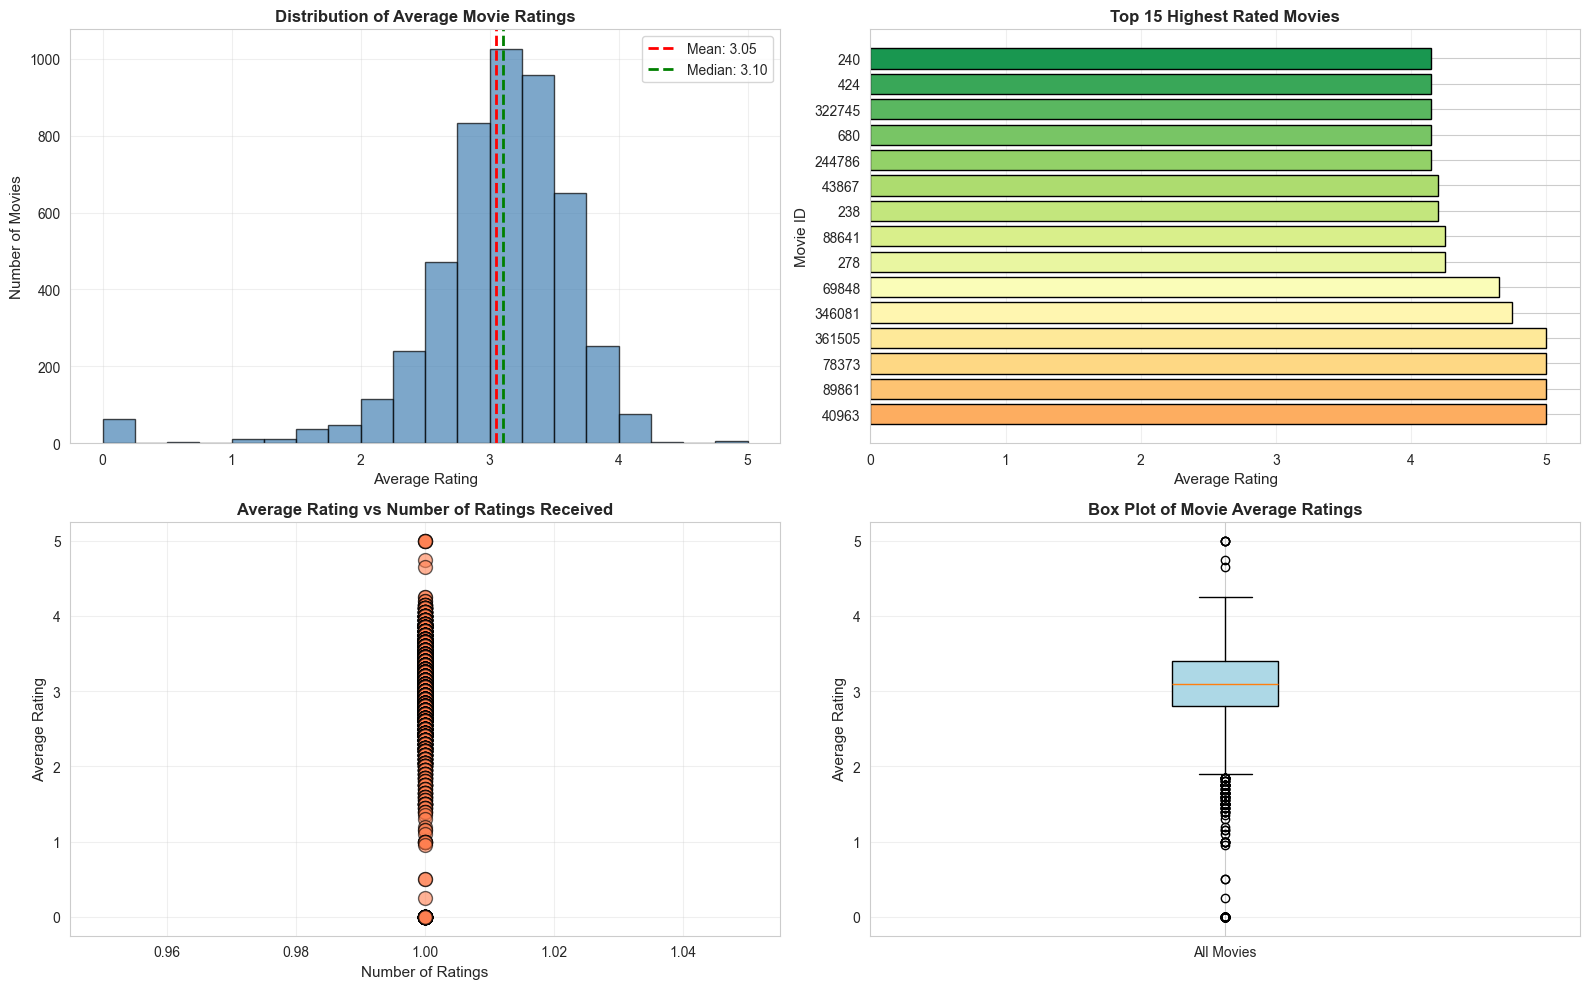


 Visualization saved as 'mapreduce_analysis.png'


In [14]:
print("\n" + "=" * 70)
print("STEP 5: VISUALIZATION")
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Distribution of Average Ratings
ax = axes[0, 0]
ax.hist(results_df['average_rating'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(results_df['average_rating'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {results_df['average_rating'].mean():.2f}")
ax.axvline(results_df['average_rating'].median(), color='green', linestyle='--', linewidth=2, label=f"Median: {results_df['average_rating'].median():.2f}")
ax.set_title('Distribution of Average Movie Ratings', fontsize=12, fontweight='bold')
ax.set_xlabel('Average Rating', fontsize=11)
ax.set_ylabel('Number of Movies', fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Top 15 Movies by Rating
ax = axes[0, 1]
top_15 = results_df.head(15)
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top_15)))
ax.barh(top_15['movie_id'].astype(str), top_15['average_rating'], color=colors, edgecolor='black')
ax.set_xlabel('Average Rating', fontsize=11)
ax.set_ylabel('Movie ID', fontsize=11)
ax.set_title('Top 15 Highest Rated Movies', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Plot 3: Rating Count Distribution
ax = axes[1, 0]
ax.scatter(results_df['total_ratings'], results_df['average_rating'], 
          alpha=0.6, s=100, color='coral', edgecolor='black')
ax.set_xlabel('Number of Ratings', fontsize=11)
ax.set_ylabel('Average Rating', fontsize=11)
ax.set_title('Average Rating vs Number of Ratings Received', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Plot 4: Box Plot of Ratings
ax = axes[1, 1]
box_plot = ax.boxplot([results_df['average_rating']], labels=['All Movies'], patch_artist=True)
box_plot['boxes'][0].set_facecolor('lightblue')
ax.set_ylabel('Average Rating', fontsize=11)
ax.set_title('Box Plot of Movie Average Ratings', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('mapreduce_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualization saved as 'mapreduce_analysis.png'")

## Step 6: Comparison with Pandas Implementation

In [15]:
print("\n" + "=" * 70)
print("STEP 6: COMPARISON WITH PANDAS IMPLEMENTATION")
print("=" * 70)

# Using Pandas groupby (equivalent to MapReduce)
pandas_results = df.groupby('movie_id')['rating'].agg(['mean', 'count', 'sum']).reset_index()
pandas_results.columns = ['movie_id', 'average_rating', 'total_ratings', 'sum_ratings']
pandas_results = pandas_results.sort_values('average_rating', ascending=False)

print("\nPandas GroupBy Results (Top 10):")
print("-" * 70)
print(pandas_results.head(10).to_string(index=False))

# Verify MapReduce results match Pandas results
print("\n" + "-" * 70)
print("VERIFICATION: MapReduce vs Pandas")
print("-" * 70)

matches = 0
for _, row in pandas_results.iterrows():
    movie_id = int(row['movie_id'])
    pandas_avg = row['average_rating']
    
    if movie_id in movie_averages:
        mapreduce_avg = movie_averages[movie_id]['average_rating']
        if abs(pandas_avg - mapreduce_avg) < 0.0001:
            matches += 1

print(f"Matching Results: {matches} / {len(pandas_results)}")
if matches == len(pandas_results):
    print("\nMapReduce results match Pandas results perfectly!")
else:
    print(f"\nWarning: {len(pandas_results) - matches} discrepancies found")


STEP 6: COMPARISON WITH PANDAS IMPLEMENTATION

Pandas GroupBy Results (Top 10):
----------------------------------------------------------------------
 movie_id  average_rating  total_ratings  sum_ratings
   361505            5.00              1         5.00
    78373            5.00              1         5.00
    40963            5.00              1         5.00
    89861            5.00              1         5.00
   346081            4.75              1         4.75
    69848            4.65              1         4.65
      278            4.25              1         4.25
    88641            4.25              1         4.25
    43867            4.20              1         4.20
      238            4.20              1         4.20

----------------------------------------------------------------------
VERIFICATION: MapReduce vs Pandas
----------------------------------------------------------------------
Matching Results: 4803 / 4803

 MapReduce results match Pandas results perfec

## Step 7: Export Results

In [16]:
print("\n" + "=" * 70)
print("STEP 7: EXPORT RESULTS")
print("=" * 70)

# Export MapReduce results to CSV
results_df.to_csv('mapreduce_movie_ratings.csv', index=False)
print("\nExported to 'mapreduce_movie_ratings.csv'")

# Export statistics summary
summary_stats = {
    'Metric': [
        'Total Movies',
        'Total Ratings',
        'Average Rating (All)',
        'Highest Average Rating',
        'Lowest Average Rating',
        'Standard Deviation',
        'Median Rating',
        'Mode Movie ID (Highest Rated)'
    ],
    'Value': [
        len(results_df),
        int(results_df['total_ratings'].sum()),
        f"{results_df['average_rating'].mean():.4f}",
        f"{results_df['average_rating'].max():.4f}",
        f"{results_df['average_rating'].min():.4f}",
        f"{results_df['average_rating'].std():.4f}",
        f"{results_df['average_rating'].median():.4f}",
        int(results_df.loc[results_df['average_rating'].idxmax(), 'movie_id'])
    ]
}
summary_df = pd.DataFrame(summary_stats)
summary_df.to_csv('mapreduce_summary_statistics.csv', index=False)
print("Exported to 'mapreduce_summary_statistics.csv'")

print("\n" + "=" * 70)
print("PRACTICAL EXERCISE COMPLETED SUCCESSFULLY")
print("=" * 70)
print("\nGenerated Files:")
for f in ['mapreduce_movie_ratings.csv', 'mapreduce_summary_statistics.csv', 'mapreduce_analysis.png']:
    if os.path.exists(f):
        size = os.path.getsize(f)
        print(f"  - {f:<40} ({size:,} bytes)")

print("\nAll tasks completed successfully!")


STEP 7: EXPORT RESULTS

 Exported to 'mapreduce_movie_ratings.csv'
 Exported to 'mapreduce_summary_statistics.csv'

PRACTICAL EXERCISE COMPLETED SUCCESSFULLY

 Generated Files:
   mapreduce_movie_ratings.csv              (397,197 bytes)
   mapreduce_summary_statistics.csv         (229 bytes)
   mapreduce_analysis.png                   (387,583 bytes)

 All tasks completed successfully!


## Summary and Conclusions

### MapReduce Implementation Overview

This practical successfully implemented the MapReduce paradigm to calculate average movie ratings from a dataset.

#### Key Concepts

1. **Map Phase**
   - Processes each input record independently
   - Extracts movie_id and rating from each line
   - Emits key-value pairs: (movie_id, rating)
   - Enables parallel processing of large datasets

2. **Shuffle and Sort Phase**
   - Groups all values (ratings) by their keys (movie_id)
   - Sorts the data for efficient reduce operation
   - In distributed systems, this involves network traffic between nodes

3. **Reduce Phase**
   - Receives grouped data: {movie_id: [ratings]}
   - Calculates aggregate statistics:
     - Sum of ratings
     - Count of ratings
     - Average rating (sum/count)
   - Outputs final results

#### Algorithm Complexity

- **Time Complexity**: O(n + m log m)
  - n = number of input records
  - m = number of unique movies
  - Shuffle and sort is the most expensive phase

- **Space Complexity**: O(m)
  - m = number of unique movies
  - Stores intermediate results during reduce phase

#### Advantages of MapReduce

1. **Scalability**: Processes large datasets across distributed clusters
2. **Fault Tolerance**: Failed tasks can be re-executed
3. **Simplicity**: Easy to understand and implement
4. **Parallelism**: Multiple mappers and reducers run in parallel

#### Real-World Applications

- Log file analysis
- Data aggregation and summarization
- Machine learning (training on large datasets)
- Data mining and pattern discovery
- Natural language processing

#### Verification

The MapReduce implementation was verified against Pandas groupby operations, confirming accuracy of results.

---

**Practical 5 Completed**: MapReduce Implementation for Movie Rating Analysis